In [47]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
import random
import matplotlib.pyplot as plt
import numpy as np
import pathlib
from scipy.signal import find_peaks
from src.controllers.pid import PIDController
from src.config.models.dual_rotor_beam_drone import DualRotorBeamDroneModel, DualRotorBeamDroneConfig

In [49]:
drone_config = DualRotorBeamDroneConfig(
    length=0.3,
    mass=0.5,
    motor_base_thrust=5.0,
    max_thrust=15.0,
    min_thrust=0.0,
    gravity=9.81,
    angular_damping=0.0
)
drone = DualRotorBeamDroneModel(config=drone_config)


In [50]:
target = 0.0
current_angle = -25.0
angular_velocity = 0.0

time = 10.0
dt = 0.01

kp = 0.5
ki = 0.0
kd = 0.0

def run_simulation(kp, ki, kd, dt=0.01, time=10.0):
    total_steps = int(time / dt)
    pid = PIDController(kp=kp, ki=ki, kd=kd, dt=dt, max_integral_error=10.0)
    pid.reset()

    current_angle = -25.0
    angular_velocity = 0.0

    target_angle_history = []
    current_angle_history = []
    time_history = []

    for step in range(total_steps):
        current_time = step * dt

        current_angle = drone.get_current_angle(current_angle)

        pid_output = pid.compute(target, current_angle)

        next_angle, next_angular_velocity, angular_acc, control = drone.step(
            angle=current_angle,
            angular_velocity=angular_velocity,
            pid_output=pid_output,
            dt=dt
        )

        angular_velocity = next_angular_velocity
        current_angle = next_angle

        target_angle_history.append(target)
        current_angle_history.append(current_angle)
        time_history.append(current_time)

    return time_history, target_angle_history, current_angle_history

time_history, target_angle_history, current_angle_history = run_simulation(kp, ki, kd, dt=dt, time=time)

In [51]:
def plot_results(time_history, target_angle_history, current_angle_history, title, text=None, save_path=None):
    plt.figure(figsize=(10, 5))
    plt.plot(time_history, current_angle_history, label='Current Angle (degrees)')
    plt.plot(time_history, target_angle_history, label='Target Angle (degrees)')
    plt.xlabel('Time (s)')
    plt.ylabel('Angle (degrees)')
    plt.title(title)
    
    # Render text box if text is passed
    if text:
        box_props = dict(boxstyle='round,pad=0.5', facecolor='whitesmoke', edgecolor='gray', alpha=0.85)

        plt.gca().text(
            0.98, 0.05, text, 
            transform=plt.gca().transAxes, 
            verticalalignment='bottom',
            horizontalalignment='right',
            fontsize=10, 
            bbox=box_props
        )
    
    # Move legend to upper right to prevent overlapping with the text box
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()

    if save_path:
        save_path = pathlib.Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

stats_info = (
    f"  Kp = {kp:.2f}\n"
    f"  Ki = {ki:.2f}\n"
    f"  Kd = {kd:.2f}"
)

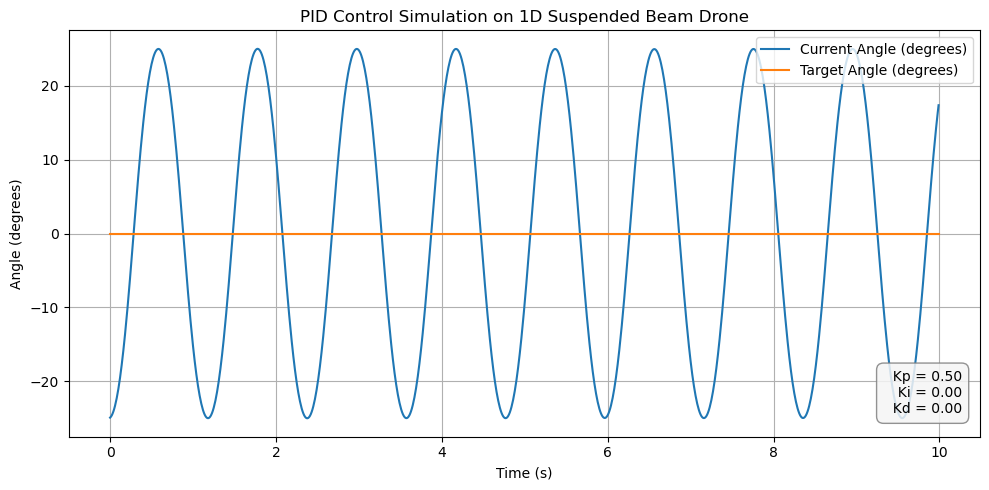

In [52]:
plot_results(time_history, target_angle_history, current_angle_history, "PID Control Simulation on 1D Suspended Beam Drone", text=stats_info)

In [53]:
angles = np.array(current_angle_history, dtype=np.float32)
peaks, properties = find_peaks(angles)
is_oscillation_stable = False
tu = None # Ultimate period in seconds
if len(peaks) >= 2:
    peak_intervals = np.diff(peaks) 
    peak_heights = angles[peaks]
    
    # Measure stability (low variance in spacing & peak heights)
    period_std = np.std(peak_intervals)
    height_std = np.std(peak_heights)
    
    # Define a tolerance threshold for "stable oscillation"
    is_oscillation_stable = period_std < 1.0 and height_std < 0.1

    avg_period_samples = np.mean(peak_intervals)
    period_seconds = avg_period_samples * dt
    tu = period_seconds

    print(f"Detected Peak Indices: {peaks}")
    print(f"Sample Intervals Between Peaks: {peak_intervals}")
    print(f"Is Oscillation Stable? {is_oscillation_stable}")
    print(f"Average Period (Samples): {avg_period_samples:.2f} samples")
    print(f"Average Period (Time): {period_seconds:.4f} s")
else:
    print("Not enough peaks detected to evaluate oscillation.")

Detected Peak Indices: [ 58 178 297 417 537 656 776 895]
Sample Intervals Between Peaks: [120 119 120 120 119 120 119]
Is Oscillation Stable? True
Average Period (Samples): 119.57 samples
Average Period (Time): 1.1957 s


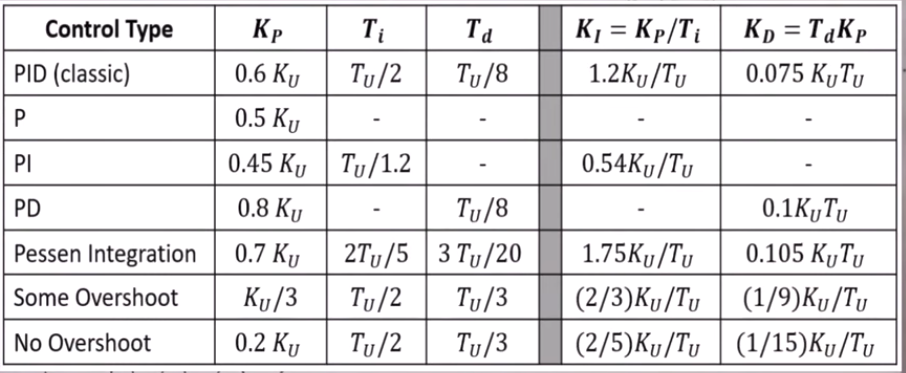
Tunning Table from Christopher Lum - https://www.youtube.com/watch?v=n829SwSUZ_c
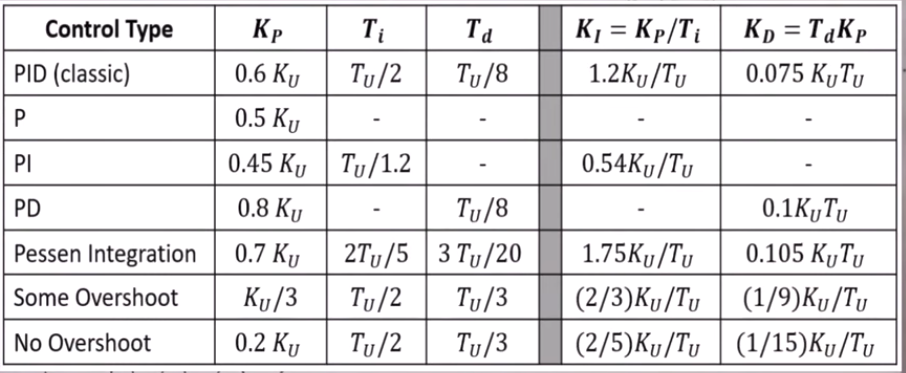

Ultimate Gain (Ku): 0.5
Ultimate Period (Tu): 1.1957 s

Classic Tuning:
kp: 0.3000, ki: 0.5018, kd: 0.0448


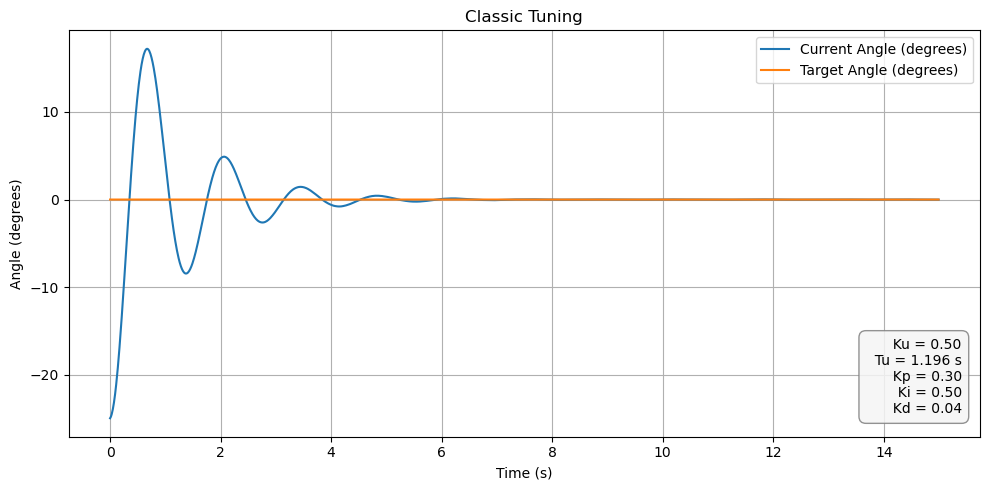


P Tuning:
kp: 0.2500, ki: 0.0000, kd: 0.0000


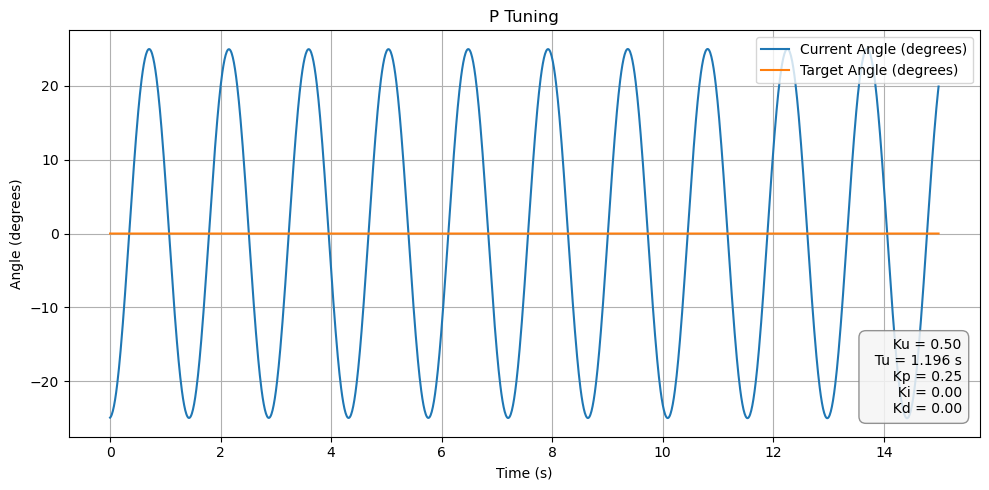


Pi Tuning:
kp: 0.2250, ki: 0.2258, kd: 0.0000


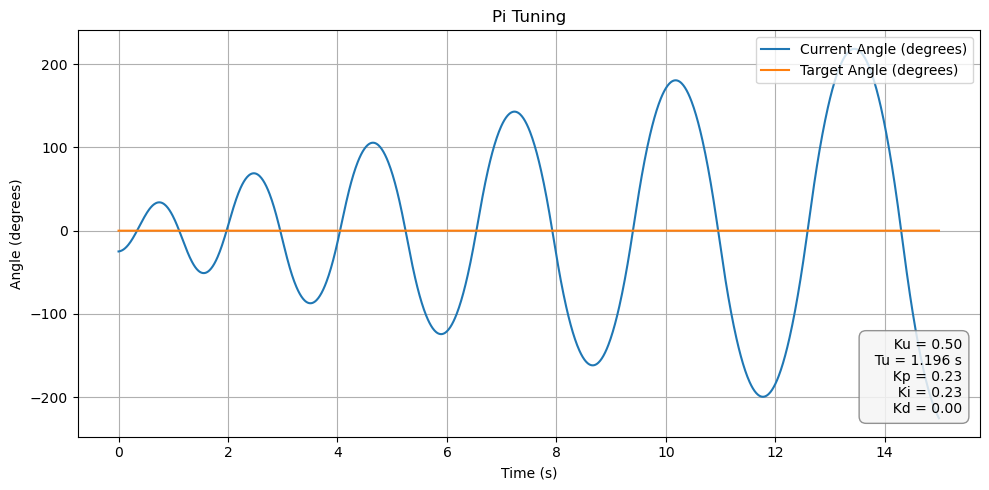


Pd Tuning:
kp: 0.4000, ki: 0.0000, kd: 0.0598


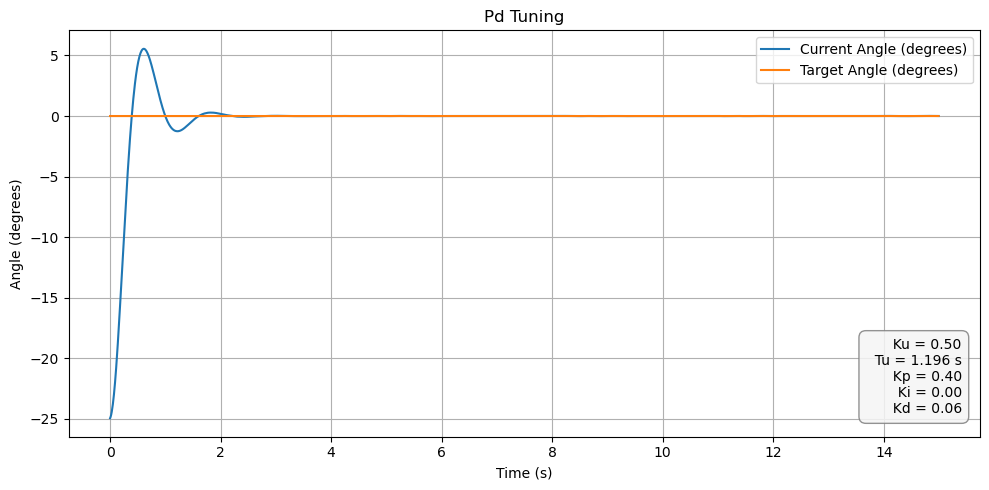


Pessen Tuning:
kp: 0.3500, ki: 0.7318, kd: 0.0628


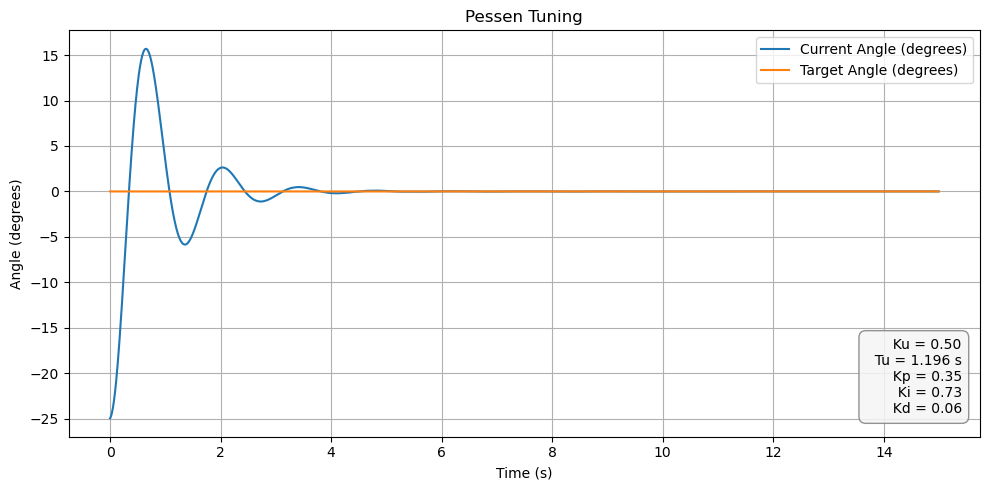


Some_overshoot Tuning:
kp: 0.1667, ki: 0.2788, kd: 0.0664


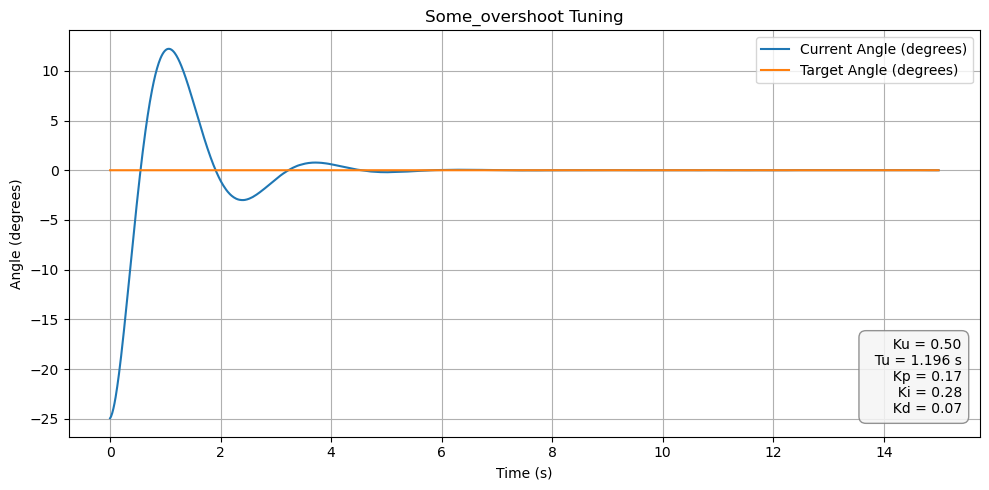


No_overshoot Tuning:
kp: 0.1000, ki: 0.1673, kd: 0.0399


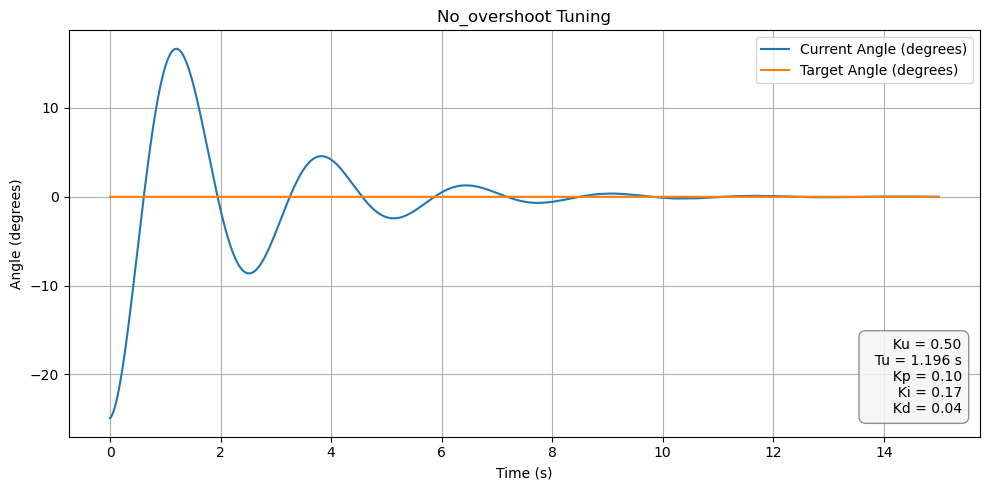

In [54]:
if is_oscillation_stable and tu is not None:
    ku = kp  # Ultimate gain
    print(f"Ultimate Gain (Ku): {ku}")
    print(f"Ultimate Period (Tu): {tu:.4f} s")

    # Ziegler-Nichols PID Tuning Rules
    rules = {
        "classic": {
            "kp": 0.6 * ku,
            "ki": 1.2 * ku / tu,
            "kd": 0.075 * ku * tu
        },
        "p": {
            "kp": 0.5 * ku,
            "ki": 0.0,
            "kd": 0.0
        },
        "pi": {
            "kp": 0.45 * ku,
            "ki": 0.54 * ku / tu,
            "kd": 0.0
        },
        "pd": {
            "kp": 0.8 * ku,
            "ki": 0.0,
            "kd": 0.1 * ku * tu
        },
        "pessen": {
            "kp": 0.7 * ku,
            "ki": 1.75 * ku / tu,
            "kd": 0.105 * ku * tu
        },
        "some_overshoot": {
            "kp": ku / 3.0,
            "ki": (2.0 / 3.0) * ku / tu,
            "kd": (1.0 / 9.0) * ku * tu
        },
        "no_overshoot": {
            "kp": 0.2 * ku,
            "ki": (2.0 / 5.0) * ku / tu,
            "kd": (1.0 / 15.0) * ku * tu
        }
    }
    for rule_name, params in rules.items():
        print(f"\n{rule_name.capitalize()} Tuning:")
        kp = params['kp']
        ki = params['ki']
        kd = params['kd']
        print(f"kp: {kp:.4f}, ki: {ki:.4f}, kd: {kd:.4f}")
        stats_info = (
            f"  Ku = {ku:.2f}\n"
            f"  Tu = {tu:.3f} s\n"
            f"  Kp = {kp:.2f}\n"
            f"  Ki = {ki:.2f}\n"
            f"  Kd = {kd:.2f}"
        )
        time_history, target_angle_history, current_angle_history = run_simulation(kp, ki, kd, time=15)
        plot_results(time_history, target_angle_history, current_angle_history, f"{rule_name.capitalize()} Tuning", text=stats_info, save_path=f"./plots/ziegler_nichols_tunned_pid/{rule_name}_tuning.png")
else:
    print("Oscillation is not stable or Tu is None. Cannot compute PID parameters.")